In [1]:
# TBN 모델 기반 RGB, Acce, Gyro 모달리티 Feature Representation T-SNE 시각화
# Multi-Modal Feature Analysis with T-SNE Visualization

import os
import sys
import json
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 프로젝트 루트 디렉토리 추가
sys.path.append('/workspace/MMEA-OWCL')

# 필요한 모듈 import
from models.baseline_tbn import TBNBaseline
from models.backbones import get_backbone
from models.model_factory import get_model
from dataloader.data_manager import TBNDataManager
from dataloader.data import iDataEgo_TBN
from dataloader.mydataset import MyDataSet
from utils.toolkit import split_images_labels

# 시각화 설정
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12
# sns.set_style("whitegrid")

print("✅ 필요한 라이브러리 및 모듈 import 완료")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 디바이스: {torch.cuda.get_device_name(0)}")

/workspace/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 필요한 라이브러리 및 모듈 import 완료
PyTorch 버전: 1.8.0+cu111
CUDA 사용 가능: True
CUDA 디바이스: NVIDIA GeForce RTX 4090


## Config

In [2]:
# 설정 및 하이퍼파라미터
class Config:
    def __init__(self):
        # 모델 설정
        self.dataset = 'dataego'
        self.modality = ['RGB', 'Acce', 'Gyro']  # 사용할 모달리티
        self.model_name = 'tbn_replay'
        self.backbone = 'tbn'
        self.arch = 'BNInception'
        self.fusion_type = 'concat'
        self.num_segments = 8
        self.batch_size = 16
        self.workers = 4
        self.dropout = 0.5
        self.init_cls = 5
        self.increment = 5
        self.shuffle = False
        self.memory_size = 0
        
        # 데이터 설정
        self.train_list = '/workspace/MMEA-OWCL/data/DataEgo/dataego_train.txt'
        self.test_list = '/workspace/MMEA-OWCL/data/DataEgo/dataego_test.txt'
        self.mpu_path = '/workspace/MMEA-OWCL/data/DataEgo/sensor/'
        
        # T-SNE 설정
        self.tsne_perplexity = 30
        self.tsne_n_iter = 1000
        self.tsne_random_state = 42
        
        # 시각화 설정
        self.max_samples_per_class = 100  # 클래스당 최대 샘플 수 (메모리 절약)
        self.tsne_samples_per_class = 50  # T-SNE 시각화용 클래스당 샘플 수
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # 모델 가중치 경로 (RGB, Acce, Gyro 모두 사용한 모델)
        self.weights_path = '/workspace/MMEA-OWCL/weights/dataego_tbn_replay_rgbaccegyro_ep50_bs8_pb1_fr0_inc5_mem320_train/Sep26_18-09-23'

config = Config()
print("✅ 설정 완료")
print(f"사용 모달리티: {config.modality}")
print(f"디바이스: {config.device}")
print(f"배치 크기: {config.batch_size}")
print(f"T-SNE perplexity: {config.tsne_perplexity}")


✅ 설정 완료
사용 모달리티: ['RGB', 'Acce', 'Gyro']
디바이스: cuda
배치 크기: 16
T-SNE perplexity: 30


## Model Load

In [3]:
# TBN 모델 로드 및 초기화
def create_tbn_model(config):
    """TBN 모델 생성 및 초기화"""
    # 작업 디렉토리를 프로젝트 루트로 변경
    original_cwd = os.getcwd()
    os.chdir('/workspace/MMEA-OWCL')
    
    try:
        args = {
            'modality': config.modality,
            'backbone': config.backbone,
            'arch': config.arch,
            'fusion_type': config.fusion_type,
            'num_segments': config.num_segments,
            'dropout': config.dropout,
            'consensus_type': 'avg',
            'before_softmax': True
        }
        
        # TBN 모델 생성
        model = TBNBaseline(args)
        model = model.to(config.device)
        model.eval()
        
        print(f"✅ TBN 모델 생성 완료")
        print(f"   모달리티: {config.modality}")
        print(f"   Feature dimension: {model.feature_dim}")
        
        return model
        
    finally:
        # 원래 작업 디렉토리로 복원
        os.chdir(original_cwd)
        

# Config 객체의 속성들을 딕셔너리로 변환
args = {}
for attr in dir(config):
    # 내장 속성은 제외
    if not attr.startswith('__'):
        args[attr] = getattr(config, attr)
args["seed"] = 1993
args["device"] = [0]
args["lr"] = 0.001
args["lr_steps"] = [10, 20]
args["momentum"] = 0.9
args["weight_decay"] = 0.0005
args["epochs"] = 50
args["clip_gradient"] = 20
args["partialbn"] = True
args["freeze"] = False
args["enable_ood"] = False
args["consensus_type"] = "avg"
args["before_softmax"] = True
# 모델 생성
# model = get_model(config.model_name, args)
model = create_tbn_model(config)
model_list = []

num_tasks = len(os.listdir(config.weights_path))
for task_id in range(num_tasks):
        print(f"\nTask {task_id + 1}/{num_tasks} Model Load")
        
        # 체크포인트 경로 찾기
        checkpoint_path = os.path.join(config.weights_path, f"task_{task_id}_checkpoint_{task_id}.pkl")
        checkpoint = torch.load(checkpoint_path)
        missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        print("missing_keys: ", missing_keys)
        print("unexpected_keys: ", unexpected_keys)
        model_list.append(copy.deepcopy(model))

Init Gyro model weight
Done. Gyro model ready.
Init Acce model weight
Done. Acce model ready.


🔍 BaselineTBN Debug:
   Modality count: 3
   Backbone feature_dim: 1024
   After fusion feature_dim: 512
✅ Baseline Model Configuration
----------------------------------------
  Backbone:        tbn
  Fusion:          concat
  Modality:        ['RGB', 'Acce', 'Gyro']
  Segments:        8
  Dropout:         0.5
  Consensus:       avg
✅ TBN 모델 생성 완료
   모달리티: ['RGB', 'Acce', 'Gyro']
   Feature dimension: 512

Task 1/4 Model Load
missing_keys:  []
unexpected_keys:  ['fc.weight', 'fc.bias', 'fc.fc_action.weight', 'fc.fc_action.bias']

Task 2/4 Model Load
missing_keys:  []
unexpected_keys:  ['fc.weight', 'fc.bias', 'fc.fc_action.weight', 'fc.fc_action.bias']

Task 3/4 Model Load
missing_keys:  []
unexpected_keys:  ['fc.weight', 'fc.bias', 'fc.fc_action.weight', 'fc.fc_action.bias']

Task 4/4 Model Load
missing_keys:  []
unexpected_keys:  ['fc.weight', 'fc.bias', 'fc.fc_action.weight', 'fc.fc_acti

## Dataset Load

In [4]:
import logging
from dataloader.data_manager import TBNDummyDataset, _get_idata, _map_new_class_index


class TBNDataManager(object):
    def __init__(self, model, image_tmpl, args):
        self.new_length = model.backbone.new_length
        self.image_tmpl = image_tmpl
        self.mpu_path = args["mpu_path"]
        self.num_segments = args["num_segments"]
        self.modality = args["modality"]

        self.dataset_name = args['dataset']
        self._setup_data(model, args['modality'], args['arch'], args['train_list'], args['test_list'],
                         args['dataset'], args['model_name'], args['shuffle'], args['seed'])
        assert args['init_cls'] <= len(self._class_order), "No enough classes."
        self._increments = [args['init_cls']]
        while sum(self._increments) + args['increment'] < len(self._class_order):
            self._increments.append(args['increment'])
        offset = len(self._class_order) - sum(self._increments)
        if offset > 0:
            self._increments.append(offset)

    @property
    def nb_tasks(self):
        return len(self._increments)

    def get_task_size(self, task):
        return self._increments[task]

    def get_total_classnum(self):
        return len(self._class_order)

    def get_dataset(
        self, indices, source, mode, appendent=None, ret_data=False, m_rate=None
    ):
        if source == "train":
            x, y = self._train_data, self._train_targets
        elif source == "test":
            x, y = self._test_data, self._test_targets
        else:
            raise ValueError("Unknown data source {}.".format(source))

        if mode == "train":
            trsf = self._train_trsf
        elif mode == "test":
            trsf = self._test_trsf
        else:
            raise ValueError("Unknown mode {}.".format(mode))

        data, targets = [], []
        for idx in indices:
            if m_rate is None:
                class_data, class_targets = self._select(
                    x, y, low_range=idx, high_range=idx + 1
                )
            else:
                class_data, class_targets = self._select_rmm(
                    x, y, low_range=idx, high_range=idx + 1, m_rate=m_rate
                )
            data.append(class_data)
            targets.append(class_targets)

        if appendent is not None and len(appendent) != 0:
            appendent_data, appendent_targets = appendent
            data.append(appendent_data)
            targets.append(appendent_targets)

        data, targets = np.concatenate(data), np.concatenate(targets)

        if ret_data:
            return data, targets, TBNDummyDataset(data, targets, self.modality,
                                               trsf, self.new_length, self.image_tmpl,
                                               self.mpu_path, self.num_segments, mode)
        else:
            return TBNDummyDataset(data, targets, self.modality,
                                trsf, self.new_length, self.image_tmpl,
                                self.mpu_path, self.num_segments, mode)

    def _setup_data(self, model, modality, arch, train_list, test_list, dataset_name, model_name, shuffle, seed):
        idata = _get_idata(dataset_name, model_name, model, modality, arch, train_list, test_list)
        idata.download_data()

        # Data
        self._train_data, self._train_targets = idata.train_data, idata.train_targets
        self._test_data, self._test_targets = idata.test_data, idata.test_targets
        self.use_path = idata.use_path

        # Transforms
        self._train_trsf = idata.train_trsf
        self._test_trsf = idata.test_trsf
        self._common_trsf = idata.common_trsf

        # Order
        order = [i for i in range(len(np.unique(self._train_targets)))]
        if shuffle:
            np.random.seed(seed)
            order = np.random.permutation(len(order)).tolist()
        else:
            order = idata.class_order
        self._class_order = order
        logging.info(self._class_order)

        # Map indices
        self._train_targets = _map_new_class_index(
            self._train_targets, self._class_order
        )
        self._test_targets = _map_new_class_index(self._test_targets, self._class_order)

    def _select(self, x, y, low_range, high_range):
        idxes = np.where(np.logical_and(y >= low_range, y < high_range))[0]
        return x[idxes], y[idxes]

    def _select_rmm(self, x, y, low_range, high_range, m_rate):
        assert m_rate is not None
        if m_rate != 0:
            idxes = np.where(np.logical_and(y >= low_range, y < high_range))[0]
            selected_idxes = np.random.randint(
                0, len(idxes), size=int((1 - m_rate) * len(idxes))
            )
            new_idxes = idxes[selected_idxes]
            new_idxes = np.sort(new_idxes)
        else:
            new_idxes = np.where(np.logical_and(y >= low_range, y < high_range))[0]
        return x[new_idxes], y[new_idxes]

    def getlen(self, index):
        y = self._train_targets
        return np.sum(np.where(y == index))


# 이미지 템플릿 설정
image_tmpl = {}
for m in config.modality:
    if m in ['RGB', 'RGBDiff']:
        image_tmpl[m] = "{:06d}.jpg"
    elif m == 'Flow':
        image_tmpl[m] = config.flow_prefix + "{}_{:06d}.jpg"

data_manager = TBNDataManager(model, image_tmpl, args)

video number:974
video number:244


## Task 1

In [6]:
# 데이터 로더 설정
def create_data_loader(config, model, task_id):
    """데이터 로더 생성"""
    # 작업 디렉토리를 프로젝트 루트로 변경
    original_cwd = os.getcwd()
    os.chdir('/workspace/MMEA-OWCL')
    
    # 이미지 템플릿 설정
    image_tmpl = {}
    for m in config["modality"]:
        if m in ['RGB', 'RGBDiff']:
            image_tmpl[m] = "{:06d}.jpg"
        elif m == 'Flow':
            image_tmpl[m] = config["flow_prefix"] + "{}_{:06d}.jpg"
    
    try:
        data_manager = TBNDataManager(model, image_tmpl, config)
        
        # Calculate total classes up to this task
        total_classes_for_task = 0
        for i in range(task_id + 1):
            total_classes_for_task += data_manager.get_task_size(i)
            
        _classes_seen_so_far = total_classes_for_task
        
        # Test data: all seen classes so far  
        test_dataset = data_manager.get_dataset(
            np.arange(0, _classes_seen_so_far), 
            source="test", 
            mode="test"
        )
        test_loader = DataLoader(
            test_dataset, batch_size=16, shuffle=False, num_workers=4
        )
        
        print(f"✅ 데이터 로더 생성 완료")
        print(f"   전체 테스트 샘플: {len(test_dataset)}")
        print(f"   클래스 수: {_classes_seen_so_far}")
        
        return test_dataset, test_loader
        
    finally:
        # 원래 작업 디렉토리로 복원
        os.chdir(original_cwd)

# 데이터 로더 생성
test_dataset, test_loader = create_data_loader(args, model, task_id=0)


video number:974
video number:244
✅ 데이터 로더 생성 완료
   전체 테스트 샘플: 63
   클래스 수: 5


In [7]:
# Feature Extraction 함수
from collections import defaultdict


def extract_individual_features(model, data_loader, config):
    """각 모달리티별로 개별 feature 추출"""
    model.eval()
    
    # 결과 저장용 딕셔너리
    features_dict = defaultdict(list)
    labels_list = []
    
    print("🔄 Feature 추출 시작...")
    
    # 작업 디렉토리를 프로젝트 루트로 변경
    original_cwd = os.getcwd()
    os.chdir('/workspace/MMEA-OWCL')
    
    try:
        with torch.no_grad():
            for idx, (_, input_dict, label) in tqdm(enumerate(data_loader), desc="Extracting features"):
                # 배치 차원 추가 및 디바이스로 이동
                for modality in config.modality:
                    input_dict[modality] = input_dict[modality].to(config.device)
                
                # Backbone을 통한 feature 추출 (fusion 이전)
                backbone_features = model.backbone(input_dict)
                
                # 각 모달리티별 feature 저장
                for i, modality in enumerate(config.modality):
                    feature = backbone_features[i].cpu().numpy().reshape(label.shape[0], -1)
                    features_dict[modality].extend(feature)
                
                labels_list.extend(label)
        
        # 리스트를 numpy 배열로 변환
        for modality in config.modality:
            features_dict[modality] = np.array(features_dict[modality])
        
        labels_array = np.array(labels_list)
        
        print("✅ Feature 추출 완료")
        for modality in config.modality:
            print(f"   {modality}: {features_dict[modality].shape}")
        print(f"   Labels: {labels_array.shape}")
        
        return features_dict, labels_array
        
    finally:
        # 원래 작업 디렉토리로 복원
        os.chdir(original_cwd)

# Feature 추출 실행
features_dict_list = []
labels_list = []
for model in model_list:
    features_dict, labels = extract_individual_features(model, test_loader, config)
    features_dict_list.append(features_dict)
    labels_list.append(labels)


🔄 Feature 추출 시작...


Extracting features: 4it [00:00,  5.26it/s]

✅ Feature 추출 완료
   RGB: (63, 8192)
   Acce: (63, 8192)
   Gyro: (63, 8192)
   Labels: (63,)
🔄 Feature 추출 시작...



Extracting features: 4it [00:00,  5.44it/s]

✅ Feature 추출 완료
   RGB: (63, 8192)
   Acce: (63, 8192)
   Gyro: (63, 8192)
   Labels: (63,)
🔄 Feature 추출 시작...



Extracting features: 4it [00:00,  5.58it/s]

✅ Feature 추출 완료
   RGB: (63, 8192)
   Acce: (63, 8192)
   Gyro: (63, 8192)
   Labels: (63,)
🔄 Feature 추출 시작...



Extracting features: 4it [00:00,  5.32it/s]

✅ Feature 추출 완료
   RGB: (63, 8192)
   Acce: (63, 8192)
   Gyro: (63, 8192)
   Labels: (63,)


📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 63 -> 선택된 샘플: 63
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.000s...
[t-SNE] Computed neighbors for 63 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 100.886803
[t-SNE] KL divergence after 250 iterations with early exaggeration: 47.793606
[t-SNE] KL divergence after 1000 iterations: 0.303042
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.000s...
[t-SNE] Computed neighbors for 63 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 0.000148
[t-SNE] KL divergence after 250 iterations with early exaggeration: 50.289570
[t-SNE] KL divergence after 1000 iterations: 0.284779
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.

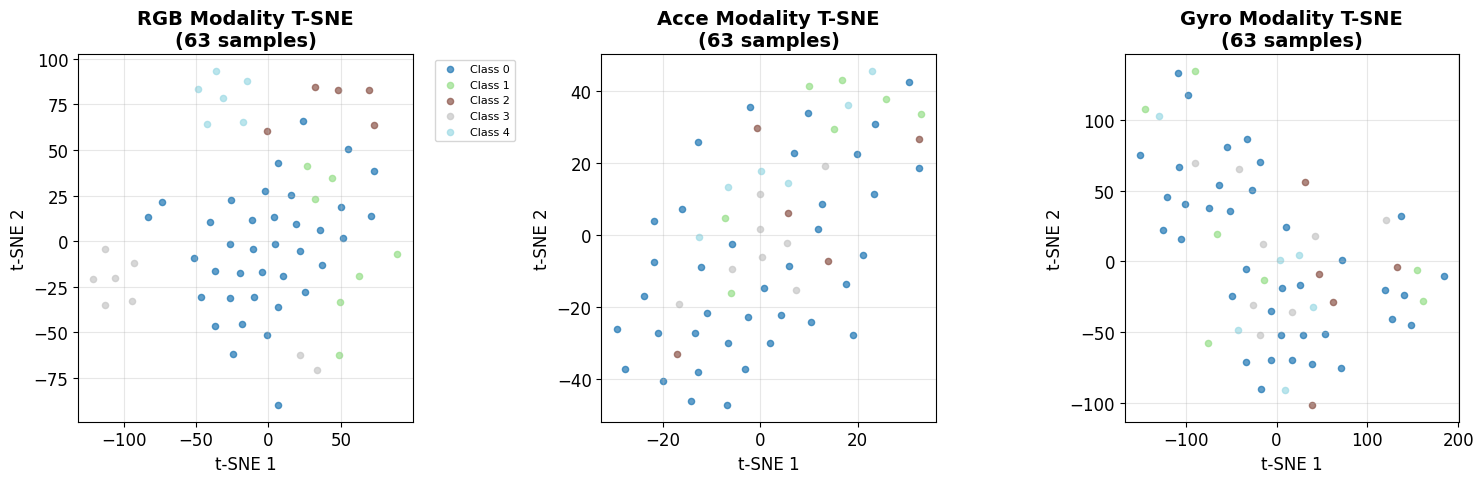

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 63 -> 선택된 샘플: 63
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.000s...
[t-SNE] Computed neighbors for 63 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 86.732247
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.830055
[t-SNE] KL divergence after 1000 iterations: 0.374973
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.001s...
[t-SNE] Computed neighbors for 63 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 115.608467
[t-SNE] KL divergence after 1000 iterations: 0.739800
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.

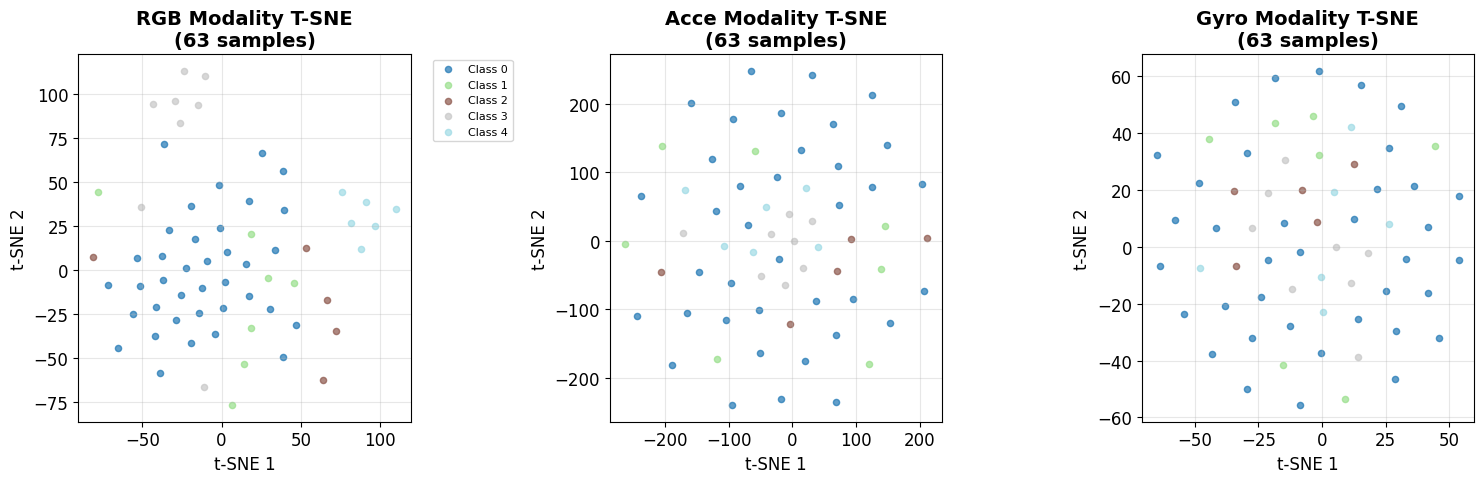

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 63 -> 선택된 샘플: 63
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.002s...
[t-SNE] Computed neighbors for 63 samples in 0.000s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 91.202937
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.216427
[t-SNE] KL divergence after 1000 iterations: 0.419465
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.008s...
[t-SNE] Computed neighbors for 63 samples in 0.000s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 98.746910
[t-SNE] KL divergence after 1000 iterations: 0.652772
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.0

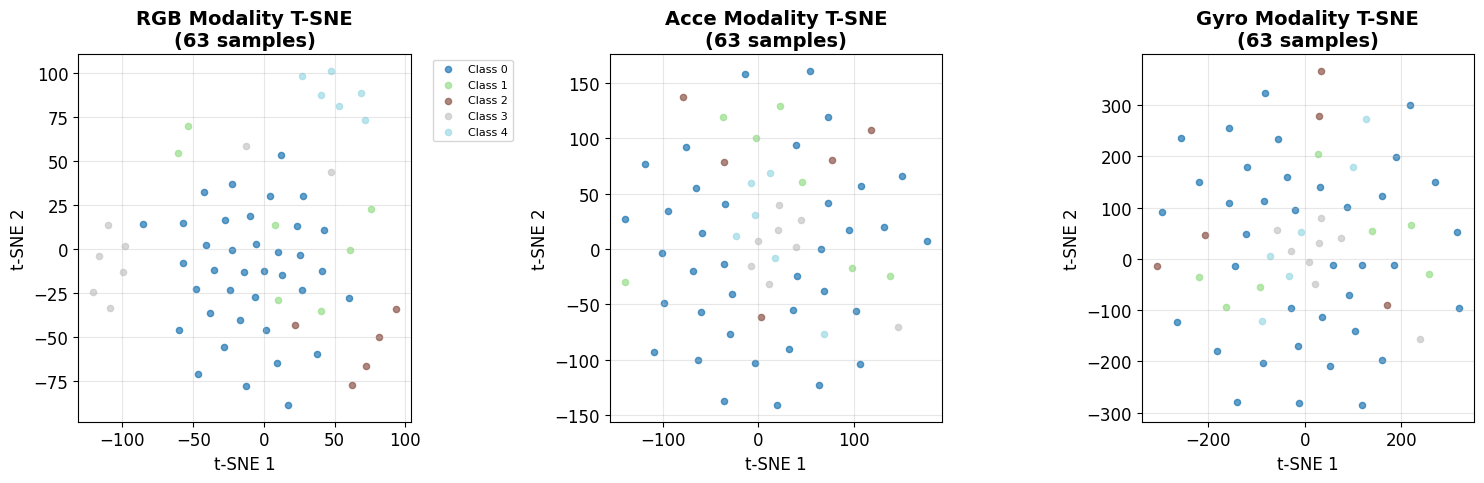

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 63 -> 선택된 샘플: 63
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.000s...
[t-SNE] Computed neighbors for 63 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 78.839240
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.988781
[t-SNE] KL divergence after 1000 iterations: 0.500344
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.000s...
[t-SNE] Computed neighbors for 63 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 63 / 63
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 115.463875
[t-SNE] KL divergence after 1000 iterations: 0.717471
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 62 nearest neighbors...
[t-SNE] Indexed 63 samples in 0.

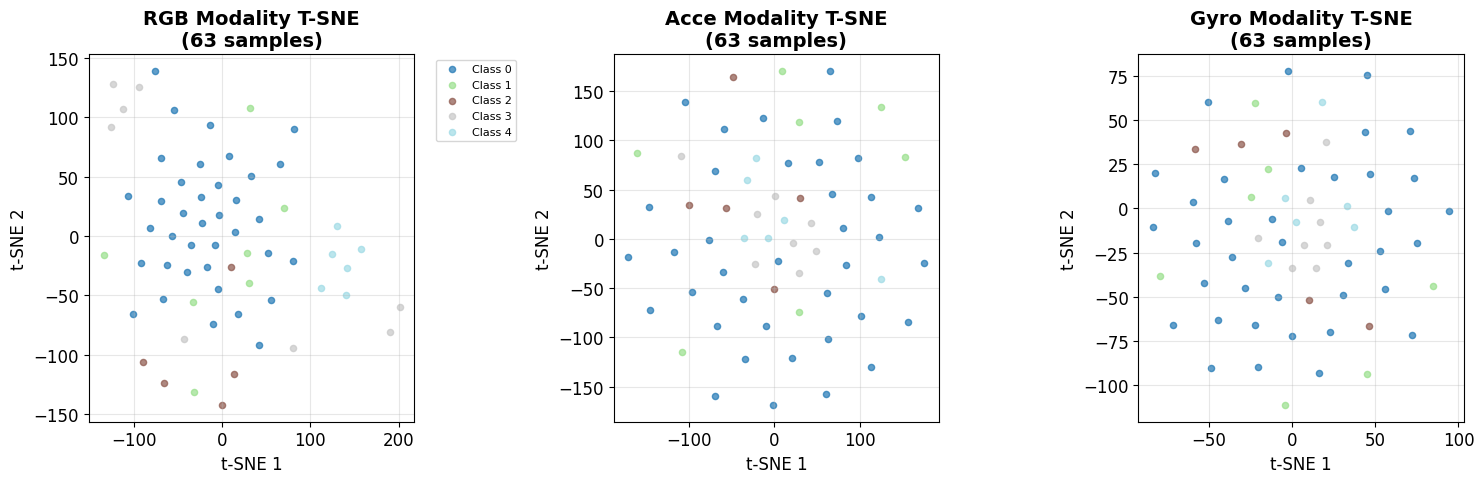

In [ ]:
# T-SNE 시각화 함수
def perform_tsne_visualization(features_dict, labels, config):
    """각 모달리티별 T-SNE 시각화 (클래스별 샘플 사이즈 제한)"""
    
    # 클래스별 샘플 사이즈 제한
    unique_classes = np.unique(labels)
    selected_indices = []
    selected_labels = []
    
    print(f"📊 클래스별 샘플 사이즈 제한: {config.tsne_samples_per_class}개")
    
    for class_id in unique_classes:
        class_indices = np.where(labels == class_id)[0]
        if len(class_indices) > config.tsne_samples_per_class:
            # 랜덤 샘플링
            np.random.seed(config.tsne_random_state)
            selected_class_indices = np.random.choice(
                class_indices, 
                config.tsne_samples_per_class, 
                replace=False
            )
        else:
            selected_class_indices = class_indices
        
        selected_indices.extend(selected_class_indices)
        selected_labels.extend([class_id] * len(selected_class_indices))
    
    selected_indices = np.array(selected_indices)
    selected_labels = np.array(selected_labels)
    
    print(f"   전체 샘플: {len(labels)} -> 선택된 샘플: {len(selected_labels)}")
    
    # 클래스별 색상 설정
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_classes)))
    class_colors = {cls: colors[i] for i, cls in enumerate(unique_classes)}
    
    # T-SNE 결과 저장
    tsne_results = {}
    
    # 각 모달리티별로 T-SNE 수행
    fig, axes = plt.subplots(1, len(config.modality), figsize=(5*len(config.modality), 5))
    if len(config.modality) == 1:
        axes = [axes]
    
    for idx, modality in enumerate(config.modality):
        print(f"🔄 {modality} 모달리티 T-SNE 수행 중...")
        
        # 선택된 샘플의 feature만 사용
        # selected_features = features_dict[modality][selected_indices]
        selected_features = features_dict[modality]
        
        # PCA로 차원 축소 (선택사항 - 메모리 절약)
        if selected_features.shape[1] > 50:
            print(f"   PCA로 차원 축소: {selected_features.shape[1]} -> 50")
            pca = PCA(n_components=50, random_state=config.tsne_random_state)
            features_pca = pca.fit_transform(selected_features)
        else:
            features_pca = selected_features
        
        # T-SNE 수행
        tsne = TSNE(
            n_components=2,
            perplexity=config.tsne_perplexity,
            n_iter=config.tsne_n_iter,
            random_state=config.tsne_random_state,
            verbose=1
        )
        
        tsne_result = tsne.fit_transform(features_pca)
        tsne_results[modality] = tsne_result
        
        # 시각화
        ax = axes[idx]
        for cls in unique_classes:
            mask = selected_labels == cls
            if np.any(mask):  # 해당 클래스의 샘플이 있는 경우만
                ax.scatter(
                    tsne_result[mask, 0], 
                    tsne_result[mask, 1],
                    c=[class_colors[cls]], 
                    label=f'Class {cls}',
                    alpha=0.7,
                    s=20
                )
        
        ax.set_title(f'{modality} Modality T-SNE\n({len(selected_labels)} samples)', fontsize=14, fontweight='bold')
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        ax.grid(True, alpha=0.3)
        
        # 범례 (첫 번째 subplot에만)
        if idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return tsne_results, selected_labels

# T-SNE 시각화 실행
tsne_results_list = []
for features_dict, labels in zip(features_dict_list, labels_list):
    tsne_results, selected_labels = perform_tsne_visualization(features_dict, labels, config)
    tsne_results_list.append(tsne_results)

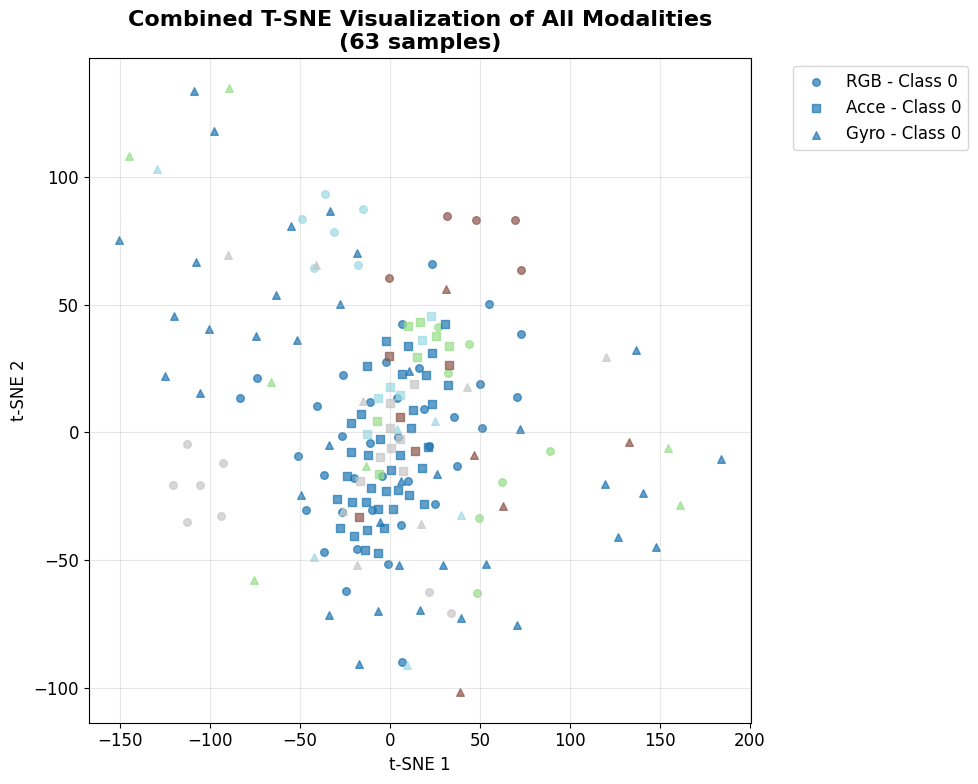

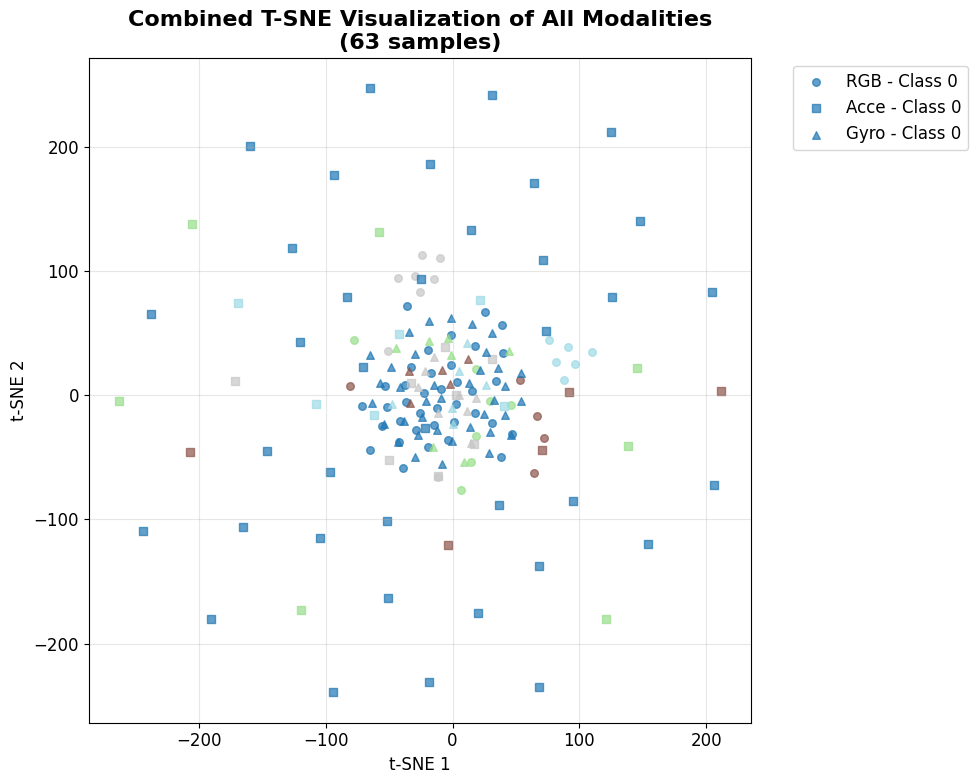

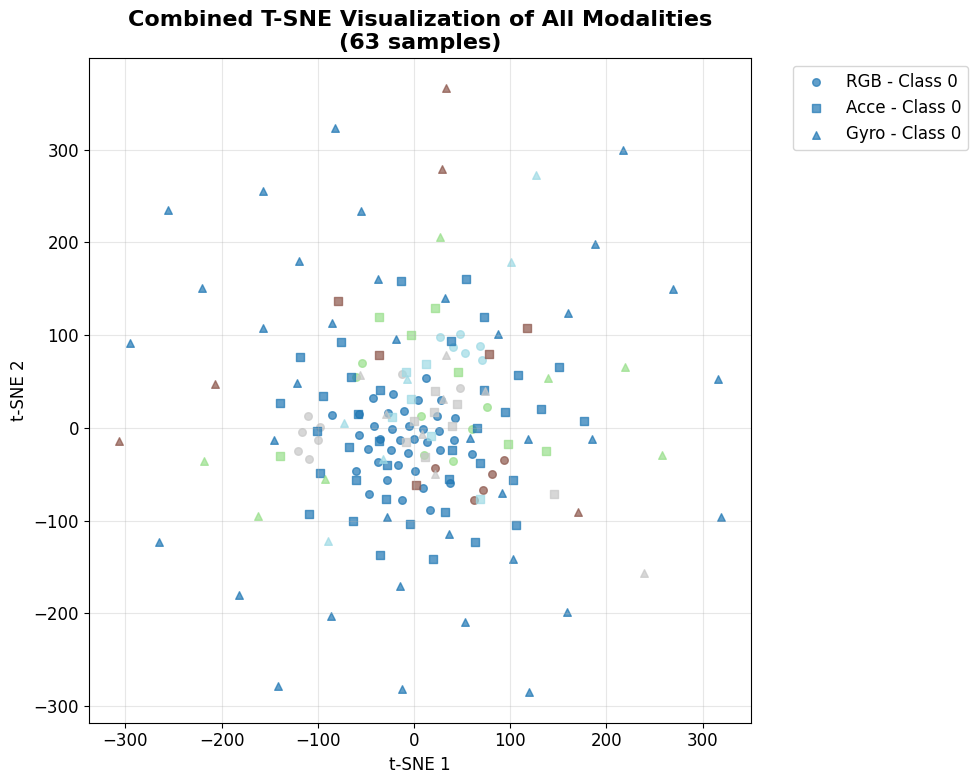

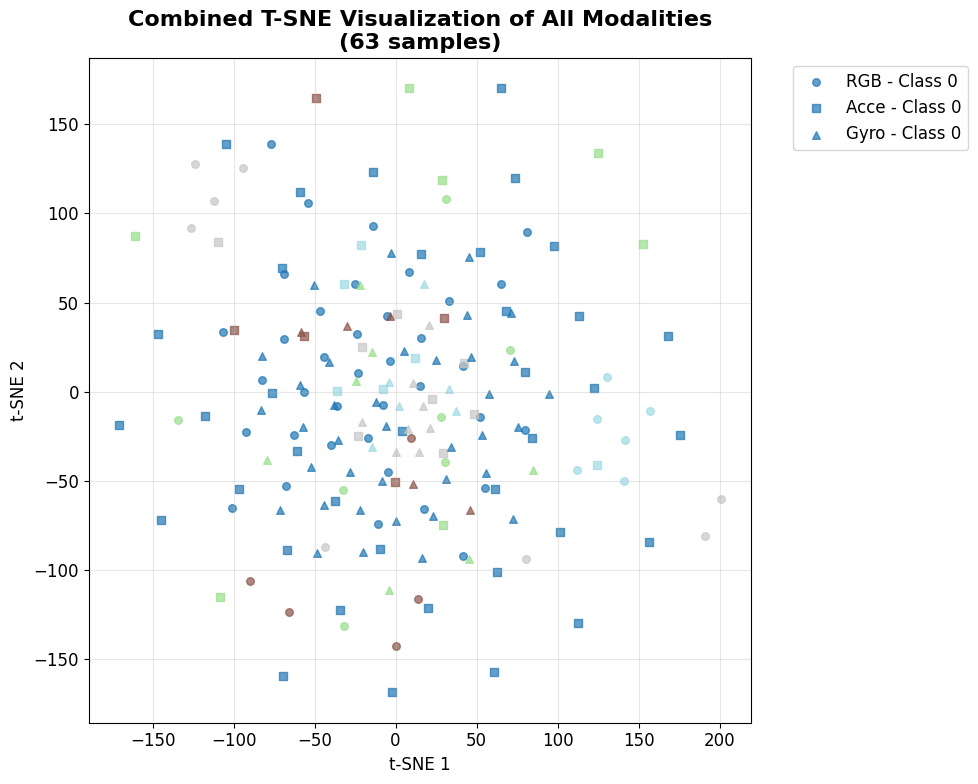

In [9]:
# 통합 T-SNE 시각화 (모든 모달리티를 하나의 플롯에)
def create_combined_tsne_visualization(tsne_results, labels, config):
    """모든 모달리티를 하나의 플롯에 표시"""
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # 클래스별 색상 설정
    unique_classes = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_classes)))
    class_colors = {cls: colors[i] for i, cls in enumerate(unique_classes)}
    
    # 모달리티별 마커 설정
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    modality_markers = {modality: markers[i] for i, modality in enumerate(config.modality)}
    
    # 각 모달리티별로 플롯
    for modality in config.modality:
        tsne_result = tsne_results[modality]
        marker = modality_markers[modality]
        
        for cls in unique_classes:
            mask = labels == cls
            if np.any(mask):  # 해당 클래스의 샘플이 있는 경우만
                ax.scatter(
                    tsne_result[mask, 0], 
                    tsne_result[mask, 1],
                    c=[class_colors[cls]], 
                    marker=marker,
                    label=f'{modality} - Class {cls}' if cls == unique_classes[0] else "",
                    alpha=0.7,
                    s=30
                )
    
    ax.set_title(f'Combined T-SNE Visualization of All Modalities\n({len(labels)} samples)', fontsize=16, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.3)
    
    # 범례 생성
    handles, labels_legend = ax.get_legend_handles_labels()
    # 중복 제거
    by_label = dict(zip(labels_legend, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 통합 시각화 실행
# create_combined_tsne_visualization(tsne_results, selected_labels, config)
for tsne_results, selected_labels in zip(tsne_results_list, labels_list):
    create_combined_tsne_visualization(tsne_results, selected_labels, config)


In [10]:
# Feature 분석 및 통계
def analyze_features(features_dict, labels, config):
    """Feature 통계 및 분석"""
    
    print("📊 Feature Analysis")
    print("=" * 50)
    
    # 각 모달리티별 feature 통계
    for modality in config.modality:
        features = features_dict[modality]
        print(f"\n🔍 {modality} Modality:")
        print(f"   Shape: {features.shape}")
        print(f"   Mean: {np.mean(features):.4f}")
        print(f"   Std: {np.std(features):.4f}")
        print(f"   Min: {np.min(features):.4f}")
        print(f"   Max: {np.max(features):.4f}")
        
        # 클래스별 feature 분포
        unique_classes = np.unique(labels)
        print(f"   클래스별 feature 평균:")
        for cls in unique_classes:
            mask = labels == cls
            cls_features = features[mask]
            print(f"     Class {cls}: {np.mean(cls_features):.4f} ± {np.std(cls_features):.4f}")
    
    # 모달리티 간 상관관계 분석
    print(f"\n🔗 Modality Correlation Analysis:")
    if len(config.modality) > 1:
        # 각 샘플에 대해 모달리티 간 상관관계 계산
        correlations = {}
        for i in range(len(config.modality)):
            for j in range(i+1, len(config.modality)):
                mod1, mod2 = config.modality[i], config.modality[j]
                # 각 샘플의 feature vector 간 코사인 유사도 계산
                features1 = features_dict[mod1]
                features2 = features_dict[mod2]
                
                # 정규화
                features1_norm = features1 / (np.linalg.norm(features1, axis=1, keepdims=True) + 1e-8)
                features2_norm = features2 / (np.linalg.norm(features2, axis=1, keepdims=True) + 1e-8)
                
                # 코사인 유사도
                cosine_sim = np.mean(np.sum(features1_norm * features2_norm, axis=1))
                correlations[f"{mod1}-{mod2}"] = cosine_sim
                print(f"   {mod1} - {mod2} Cosine Similarity: {cosine_sim:.4f}")

# Feature 분석 실행
# analyze_features(features_dict, labels, config)
for features_dict, labels in zip(features_dict_list, labels_list):
    analyze_features(features_dict, labels, config)

📊 Feature Analysis

🔍 RGB Modality:
   Shape: (63, 8192)
   Mean: 0.7793
   Std: 2.6782
   Min: 0.0000
   Max: 118.6990
   클래스별 feature 평균:
     Class 0: 0.5447 ± 1.8550
     Class 1: 0.6103 ± 1.9660
     Class 2: 1.1945 ± 3.4370
     Class 3: 1.6311 ± 4.5684
     Class 4: 0.9410 ± 3.2257

🔍 Acce Modality:
   Shape: (63, 8192)
   Mean: -0.0104
   Std: 0.0545
   Min: -0.3854
   Max: 0.2263
   클래스별 feature 평균:
     Class 0: -0.0104 ± 0.0545
     Class 1: -0.0104 ± 0.0545
     Class 2: -0.0104 ± 0.0545
     Class 3: -0.0104 ± 0.0545
     Class 4: -0.0104 ± 0.0545

🔍 Gyro Modality:
   Shape: (63, 8192)
   Mean: -0.0001
   Std: 0.0062
   Min: -0.0239
   Max: 0.0356
   클래스별 feature 평균:
     Class 0: -0.0001 ± 0.0062
     Class 1: -0.0001 ± 0.0062
     Class 2: -0.0001 ± 0.0062
     Class 3: -0.0001 ± 0.0062
     Class 4: -0.0001 ± 0.0062

🔗 Modality Correlation Analysis:
   RGB - Acce Cosine Similarity: -0.0549
   RGB - Gyro Cosine Similarity: -0.0122
   Acce - Gyro Cosine Similarity: 0.0238

## Task 2

In [12]:
# 데이터 로더 생성
test_dataset, test_loader = create_data_loader(args, model, task_id=1)

video number:974
video number:244
✅ 데이터 로더 생성 완료
   전체 테스트 샘플: 115
   클래스 수: 10


In [13]:
# Feature 추출 실행
features_dict_list = []
labels_list = []
for model in model_list:
    features_dict, labels = extract_individual_features(model, test_loader, config)
    features_dict_list.append(features_dict)
    labels_list.append(labels)

🔄 Feature 추출 시작...


Extracting features: 8it [00:01,  6.60it/s]

✅ Feature 추출 완료
   RGB: (115, 8192)
   Acce: (115, 8192)
   Gyro: (115, 8192)
   Labels: (115,)
🔄 Feature 추출 시작...



Extracting features: 8it [00:01,  6.55it/s]

✅ Feature 추출 완료
   RGB: (115, 8192)
   Acce: (115, 8192)
   Gyro: (115, 8192)
   Labels: (115,)
🔄 Feature 추출 시작...



Extracting features: 8it [00:01,  6.53it/s]

✅ Feature 추출 완료
   RGB: (115, 8192)
   Acce: (115, 8192)
   Gyro: (115, 8192)
   Labels: (115,)
🔄 Feature 추출 시작...



Extracting features: 8it [00:01,  6.69it/s]

✅ Feature 추출 완료
   RGB: (115, 8192)
   Acce: (115, 8192)
   Gyro: (115, 8192)
   Labels: (115,)


📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 115 -> 선택된 샘플: 115
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.000s...
[t-SNE] Computed neighbors for 115 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 67.361045
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.593990
[t-SNE] KL divergence after 950 iterations: 0.241680
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.001s...
[t-SNE] Computed neighbors for 115 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 0.000126
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.802467
[t-SNE] KL divergence after 750 iterations: 0.203796
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 sampl

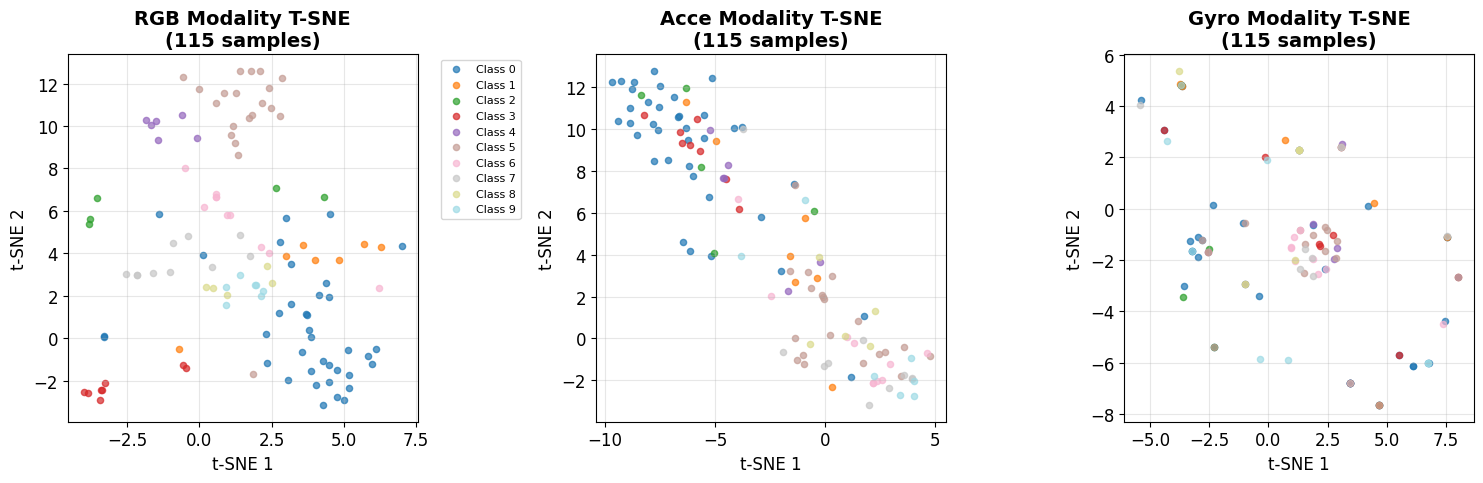

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 115 -> 선택된 샘플: 115
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.005s...
[t-SNE] Computed neighbors for 115 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 81.374141
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.498932
[t-SNE] KL divergence after 1000 iterations: 0.213707
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.000s...
[t-SNE] Computed neighbors for 115 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.629570
[t-SNE] KL divergence after 1000 iterations: 0.752435
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 sam

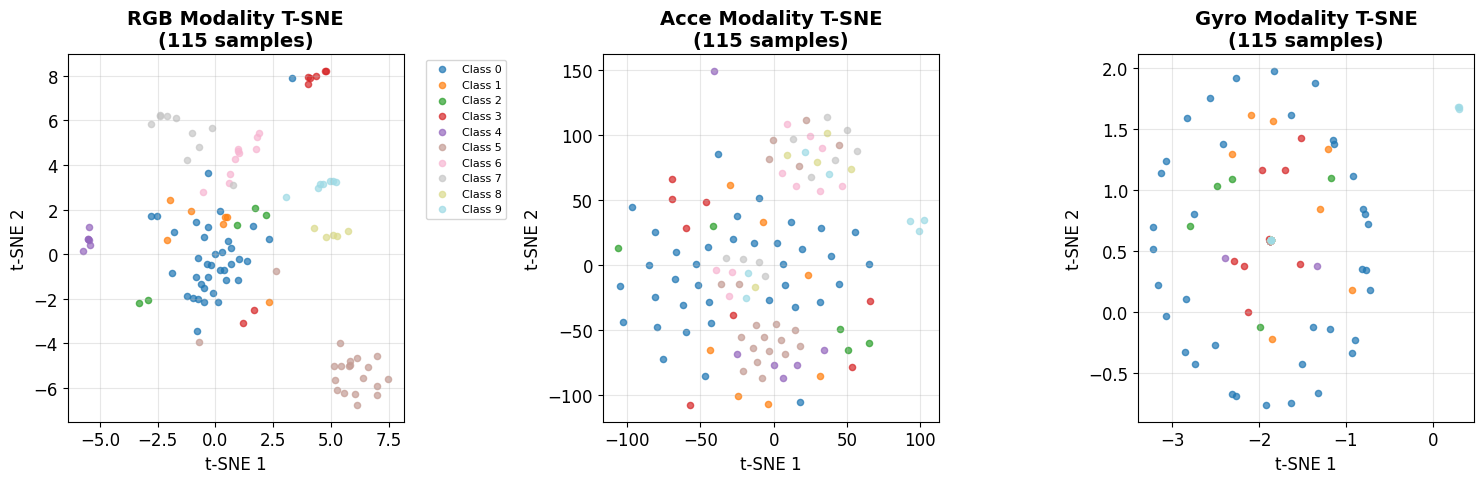

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 115 -> 선택된 샘플: 115
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.000s...
[t-SNE] Computed neighbors for 115 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 80.726900
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.801796
[t-SNE] KL divergence after 1000 iterations: 0.235916
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.004s...
[t-SNE] Computed neighbors for 115 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.915073
[t-SNE] KL divergence after 1000 iterations: 0.671910
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 sam

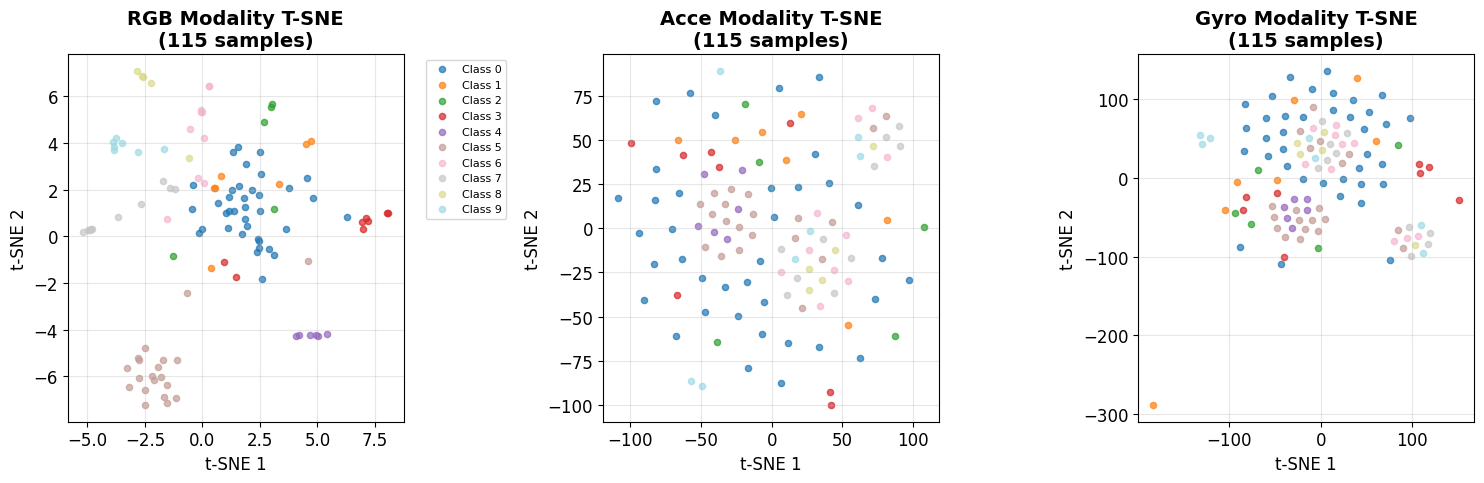

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 115 -> 선택된 샘플: 115
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.000s...
[t-SNE] Computed neighbors for 115 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 73.047819
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.377476
[t-SNE] KL divergence after 1000 iterations: 0.221001
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 samples in 0.002s...
[t-SNE] Computed neighbors for 115 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 115 / 115
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.908157
[t-SNE] KL divergence after 1000 iterations: 0.389061
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 115 sam

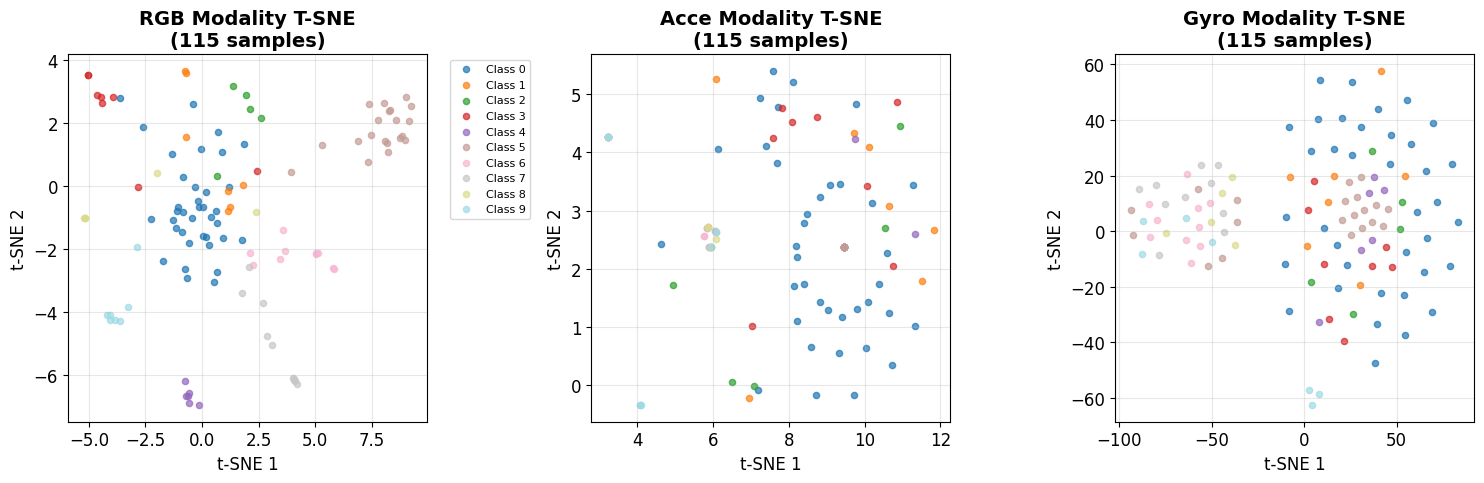

In [14]:
# T-SNE 시각화 실행
tsne_results_list = []
for features_dict, labels in zip(features_dict_list, labels_list):
    tsne_results, selected_labels = perform_tsne_visualization(features_dict, labels, config)
    tsne_results_list.append(tsne_results)

In [15]:
# Feature 분석 실행
# analyze_features(features_dict, labels, config)
for features_dict, labels in zip(features_dict_list, labels_list):
    analyze_features(features_dict, labels, config)

📊 Feature Analysis

🔍 RGB Modality:
   Shape: (115, 8192)
   Mean: 0.7764
   Std: 2.4083
   Min: 0.0000
   Max: 118.6990
   클래스별 feature 평균:
     Class 0: 0.5447 ± 1.8550
     Class 1: 0.6103 ± 1.9660
     Class 2: 1.1945 ± 3.4370
     Class 3: 1.6311 ± 4.5684
     Class 4: 0.9410 ± 3.2257
     Class 5: 0.8909 ± 2.6502
     Class 6: 0.7348 ± 1.6470
     Class 7: 0.7788 ± 1.6261
     Class 8: 0.6004 ± 1.3038
     Class 9: 0.6045 ± 1.3057

🔍 Acce Modality:
   Shape: (115, 8192)
   Mean: -0.0104
   Std: 0.0545
   Min: -0.3854
   Max: 0.2263
   클래스별 feature 평균:
     Class 0: -0.0104 ± 0.0545
     Class 1: -0.0104 ± 0.0545
     Class 2: -0.0104 ± 0.0545
     Class 3: -0.0104 ± 0.0545
     Class 4: -0.0104 ± 0.0545
     Class 5: -0.0104 ± 0.0545
     Class 6: -0.0104 ± 0.0545
     Class 7: -0.0104 ± 0.0545
     Class 8: -0.0104 ± 0.0545
     Class 9: -0.0104 ± 0.0545

🔍 Gyro Modality:
   Shape: (115, 8192)
   Mean: -0.0001
   Std: 0.0062
   Min: -0.0239
   Max: 0.0356
   클래스별 feature 평균:
   

## Task 3

In [17]:
# 데이터 로더 생성
test_dataset, test_loader = create_data_loader(args, model, task_id=2)

video number:974
video number:244
✅ 데이터 로더 생성 완료
   전체 테스트 샘플: 207
   클래스 수: 15


In [18]:
# Feature 추출 실행
features_dict_list = []
labels_list = []
for model in model_list:
    features_dict, labels = extract_individual_features(model, test_loader, config)
    features_dict_list.append(features_dict)
    labels_list.append(labels)

🔄 Feature 추출 시작...


Extracting features: 13it [00:02,  6.40it/s]

✅ Feature 추출 완료
   RGB: (207, 8192)
   Acce: (207, 8192)
   Gyro: (207, 8192)
   Labels: (207,)
🔄 Feature 추출 시작...



Extracting features: 13it [00:02,  6.29it/s]

✅ Feature 추출 완료
   RGB: (207, 8192)
   Acce: (207, 8192)
   Gyro: (207, 8192)
   Labels: (207,)
🔄 Feature 추출 시작...



Extracting features: 13it [00:02,  6.34it/s]

✅ Feature 추출 완료
   RGB: (207, 8192)
   Acce: (207, 8192)
   Gyro: (207, 8192)
   Labels: (207,)
🔄 Feature 추출 시작...



Extracting features: 13it [00:02,  6.17it/s]

✅ Feature 추출 완료
   RGB: (207, 8192)
   Acce: (207, 8192)
   Gyro: (207, 8192)
   Labels: (207,)


📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 207 -> 선택된 샘플: 207
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.004s...
[t-SNE] Computed neighbors for 207 samples in 0.031s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 48.048839
[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.595028
[t-SNE] KL divergence after 1000 iterations: 0.385031
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 0.000104
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.434547
[t-SNE] KL divergence after 1000 iterations: 0.331926
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 sam

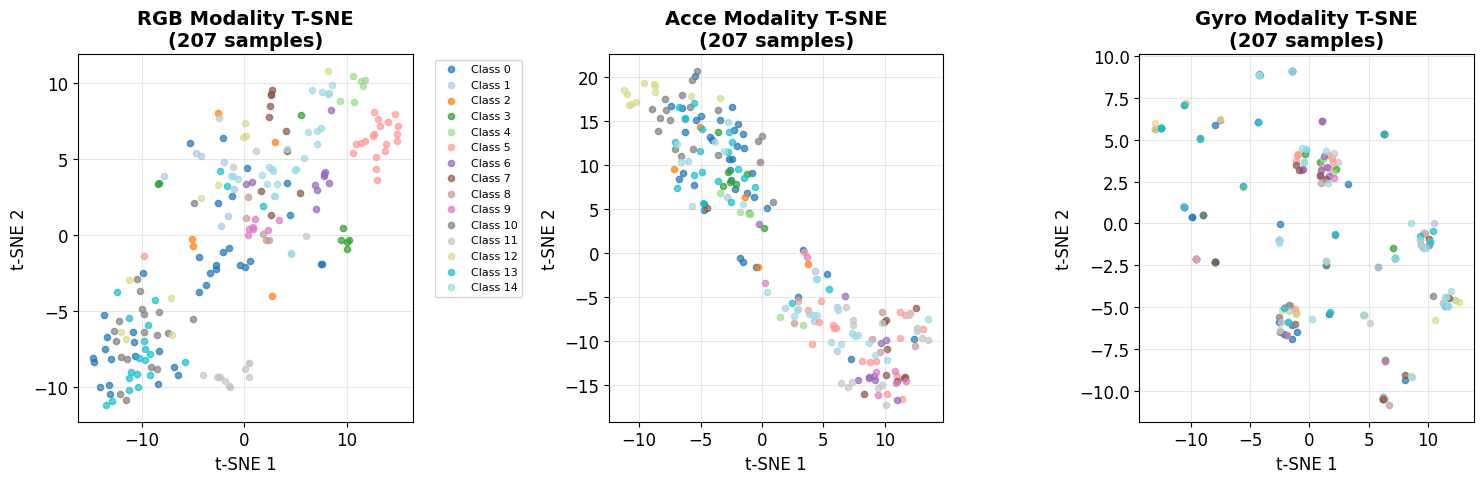

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 207 -> 선택된 샘플: 207
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 43.209487
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.299343
[t-SNE] KL divergence after 1000 iterations: 0.363434
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 47.654980
[t-SNE] KL divergence after 1000 iterations: 0.093101
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 sam

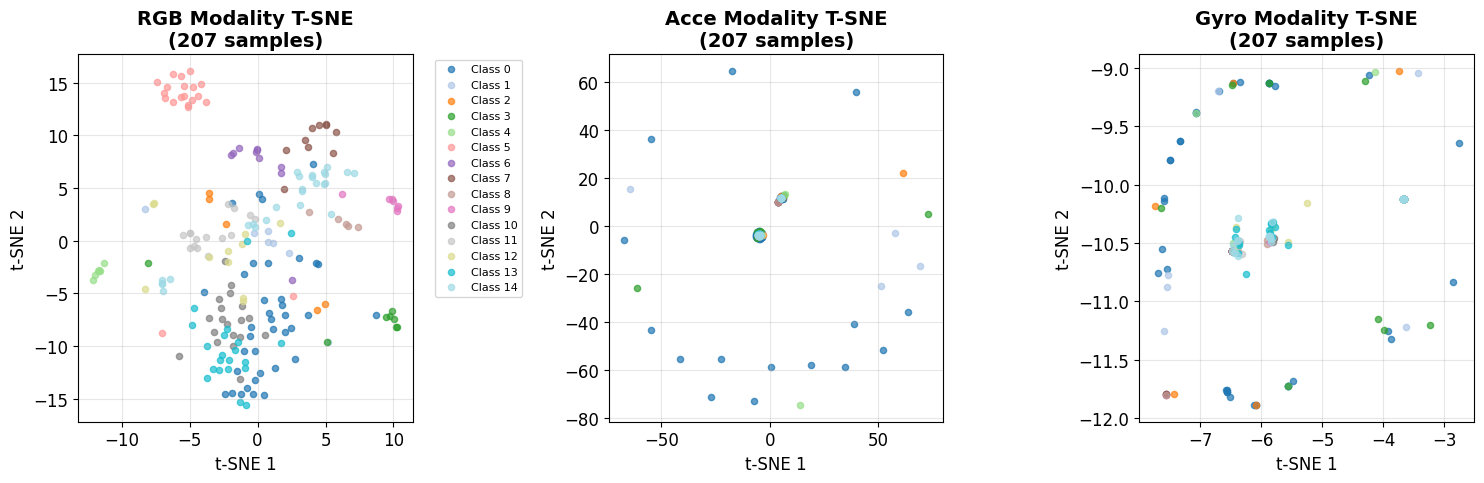

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 207 -> 선택된 샘플: 207
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 48.033492
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.894310
[t-SNE] KL divergence after 1000 iterations: 0.397467
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.633389
[t-SNE] KL divergence after 950 iterations: 0.187840
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samp

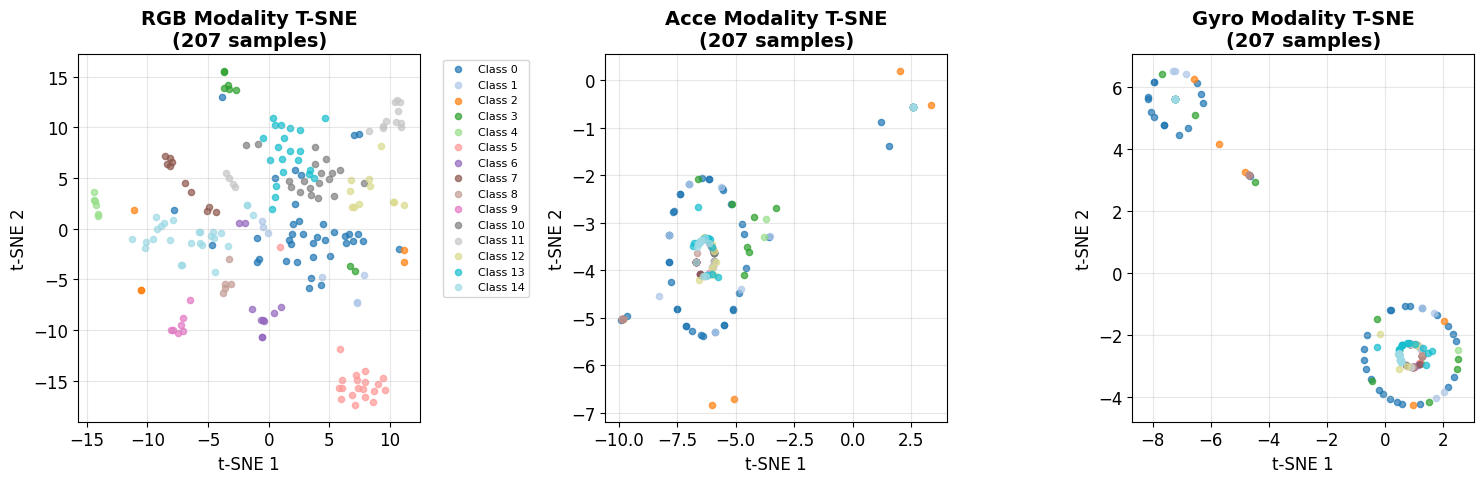

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 207 -> 선택된 샘플: 207
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 39.669822
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.314018
[t-SNE] KL divergence after 1000 iterations: 0.420486
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 samples in 0.000s...
[t-SNE] Computed neighbors for 207 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 207 / 207
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.646412
[t-SNE] KL divergence after 1000 iterations: 0.114639
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 207 sam

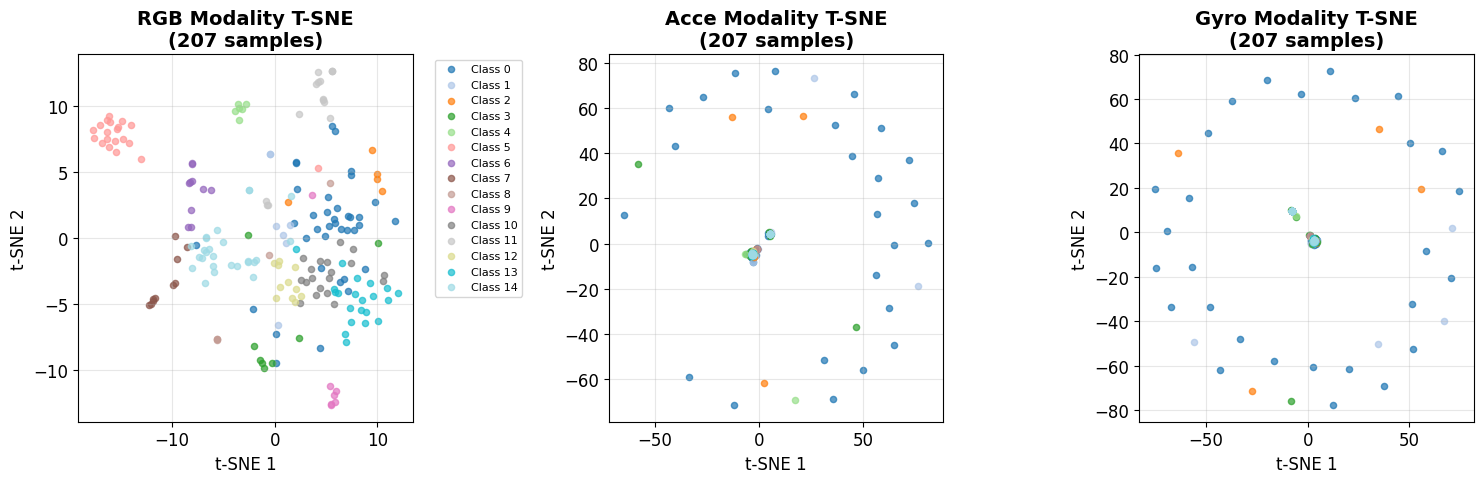

In [19]:
# T-SNE 시각화 실행
tsne_results_list = []
for features_dict, labels in zip(features_dict_list, labels_list):
    tsne_results, selected_labels = perform_tsne_visualization(features_dict, labels, config)
    tsne_results_list.append(tsne_results)

In [20]:
# Feature 분석 실행
# analyze_features(features_dict, labels, config)
for features_dict, labels in zip(features_dict_list, labels_list):
    analyze_features(features_dict, labels, config)

📊 Feature Analysis

🔍 RGB Modality:
   Shape: (207, 8192)
   Mean: 0.6666
   Std: 2.1441
   Min: 0.0000
   Max: 118.6990
   클래스별 feature 평균:
     Class 0: 0.5447 ± 1.8550
     Class 1: 0.6103 ± 1.9660
     Class 2: 1.1945 ± 3.4370
     Class 3: 1.6311 ± 4.5684
     Class 4: 0.9410 ± 3.2257
     Class 5: 0.8909 ± 2.6502
     Class 6: 0.7348 ± 1.6470
     Class 7: 0.7788 ± 1.6261
     Class 8: 0.6004 ± 1.3038
     Class 9: 0.6045 ± 1.3057
     Class 10: 0.4007 ± 1.6539
     Class 11: 0.5540 ± 2.0618
     Class 12: 0.4740 ± 1.6646
     Class 13: 0.4502 ± 1.7610
     Class 14: 0.6969 ± 1.6280

🔍 Acce Modality:
   Shape: (207, 8192)
   Mean: -0.0104
   Std: 0.0545
   Min: -0.3854
   Max: 0.2263
   클래스별 feature 평균:
     Class 0: -0.0104 ± 0.0545
     Class 1: -0.0104 ± 0.0545
     Class 2: -0.0104 ± 0.0545
     Class 3: -0.0104 ± 0.0545
     Class 4: -0.0104 ± 0.0545
     Class 5: -0.0104 ± 0.0545
     Class 6: -0.0104 ± 0.0545
     Class 7: -0.0104 ± 0.0545
     Class 8: -0.0104 ± 0.0545
  

## Task 4

In [21]:
# 데이터 로더 생성
test_dataset, test_loader = create_data_loader(args, model, task_id=3)

video number:974
video number:244
✅ 데이터 로더 생성 완료
   전체 테스트 샘플: 244
   클래스 수: 20


In [22]:
# Feature 추출 실행
features_dict_list = []
labels_list = []
for model in model_list:
    features_dict, labels = extract_individual_features(model, test_loader, config)
    features_dict_list.append(features_dict)
    labels_list.append(labels)

🔄 Feature 추출 시작...


Extracting features: 16it [00:02,  7.27it/s]

✅ Feature 추출 완료
   RGB: (244, 8192)
   Acce: (244, 8192)
   Gyro: (244, 8192)
   Labels: (244,)
🔄 Feature 추출 시작...



Extracting features: 16it [00:02,  7.21it/s]

✅ Feature 추출 완료
   RGB: (244, 8192)
   Acce: (244, 8192)
   Gyro: (244, 8192)
   Labels: (244,)
🔄 Feature 추출 시작...



Extracting features: 16it [00:02,  7.09it/s]

✅ Feature 추출 완료
   RGB: (244, 8192)
   Acce: (244, 8192)
   Gyro: (244, 8192)
   Labels: (244,)
🔄 Feature 추출 시작...



Extracting features: 16it [00:02,  7.23it/s]

✅ Feature 추출 완료
   RGB: (244, 8192)
   Acce: (244, 8192)
   Gyro: (244, 8192)
   Labels: (244,)


📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 244 -> 선택된 샘플: 244
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.000s...
[t-SNE] Computed neighbors for 244 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 45.172559
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.125858
[t-SNE] KL divergence after 1000 iterations: 0.414267
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.000s...
[t-SNE] Computed neighbors for 244 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 0.000099
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.254036
[t-SNE] KL divergence after 1000 iterations: 0.357919
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 sam

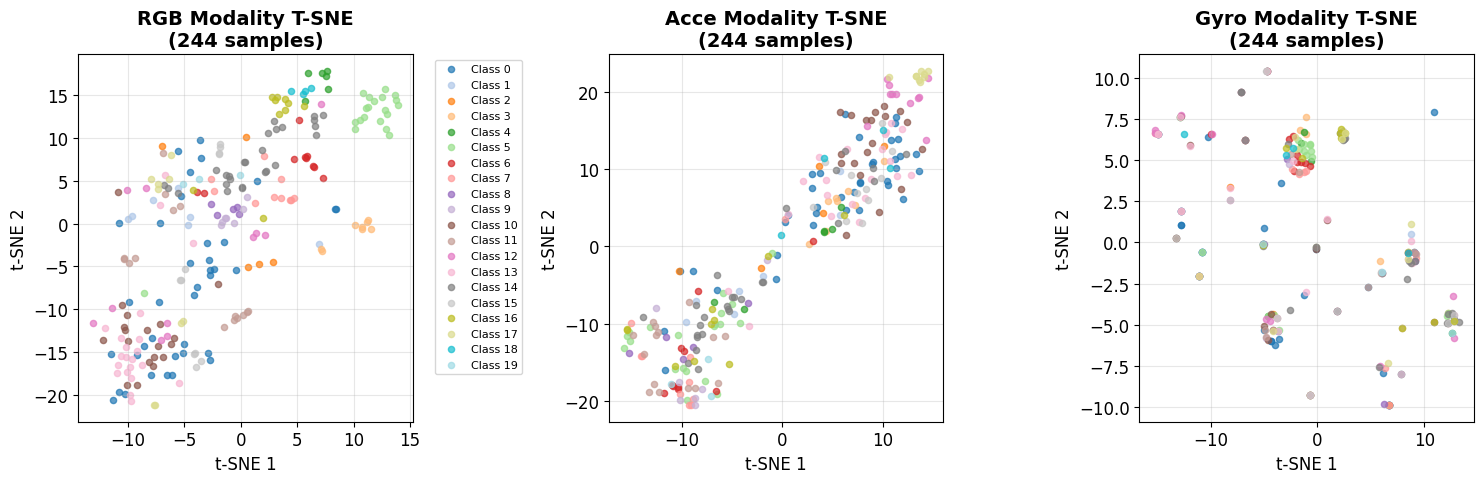

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 244 -> 선택된 샘플: 244
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.002s...
[t-SNE] Computed neighbors for 244 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 40.858327
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.364750
[t-SNE] KL divergence after 1000 iterations: 0.470631
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.004s...
[t-SNE] Computed neighbors for 244 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.105183
[t-SNE] KL divergence after 1000 iterations: 0.345600
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 sam

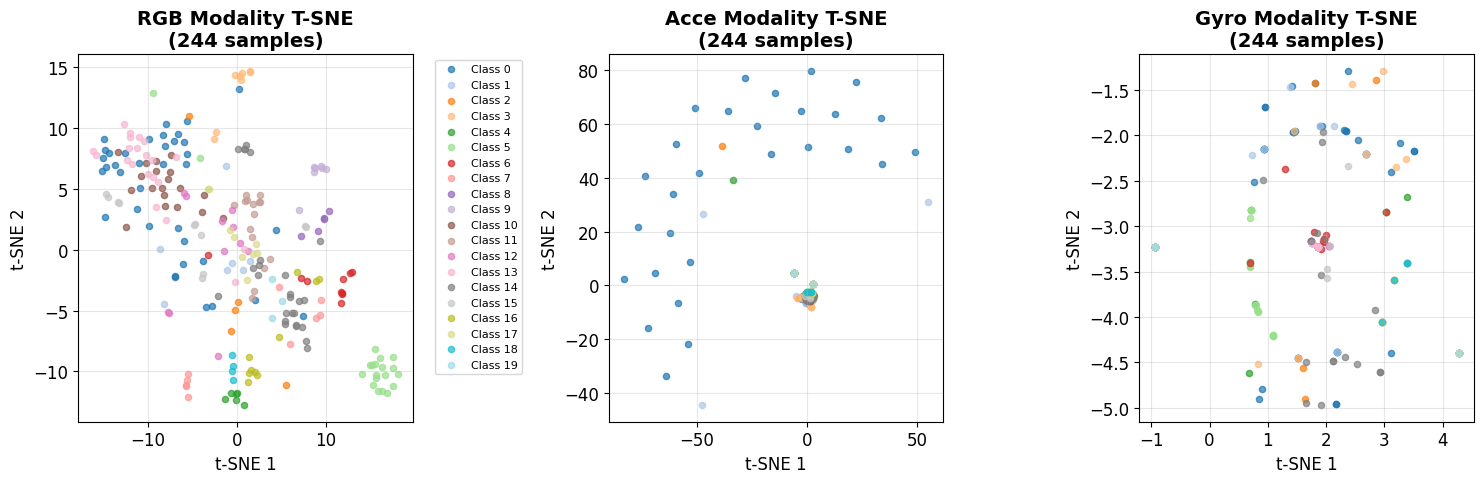

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 244 -> 선택된 샘플: 244
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.000s...
[t-SNE] Computed neighbors for 244 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 44.775468
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.387947
[t-SNE] KL divergence after 1000 iterations: 0.442751
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.000s...
[t-SNE] Computed neighbors for 244 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.842422
[t-SNE] KL divergence after 1000 iterations: 0.365698
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 sam

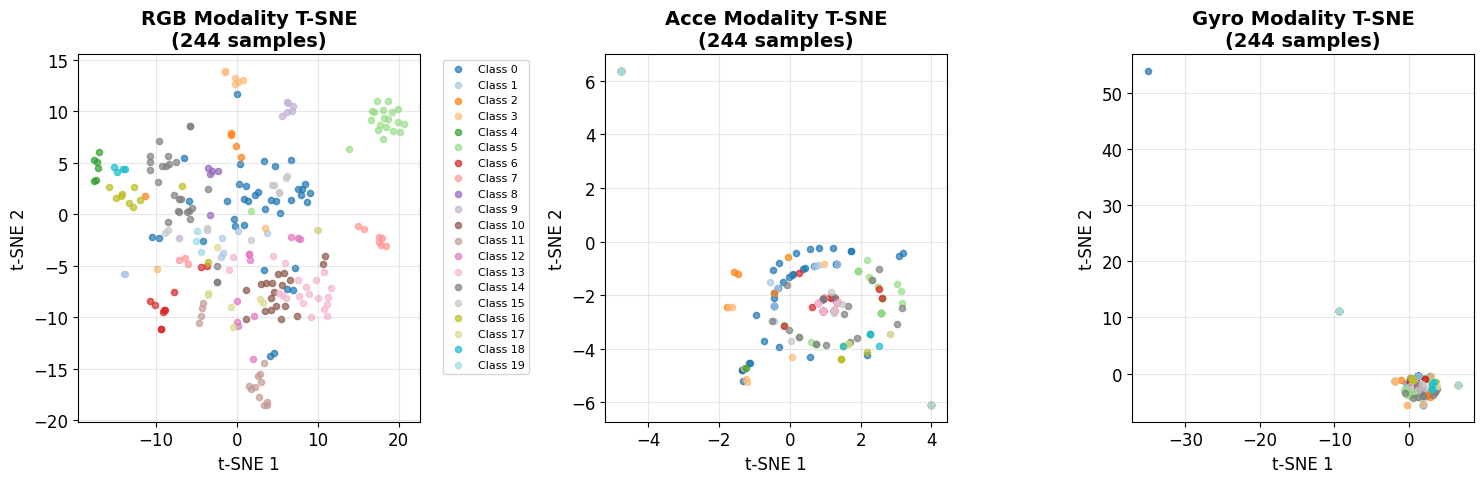

📊 클래스별 샘플 사이즈 제한: 50개
   전체 샘플: 244 -> 선택된 샘플: 244
🔄 RGB 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.000s...
[t-SNE] Computed neighbors for 244 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 39.960050
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.044289
[t-SNE] KL divergence after 1000 iterations: 0.413382
🔄 Acce 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 samples in 0.000s...
[t-SNE] Computed neighbors for 244 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 244 / 244
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.660553
[t-SNE] KL divergence after 1000 iterations: 0.311873
🔄 Gyro 모달리티 T-SNE 수행 중...
   PCA로 차원 축소: 8192 -> 50
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 244 sam

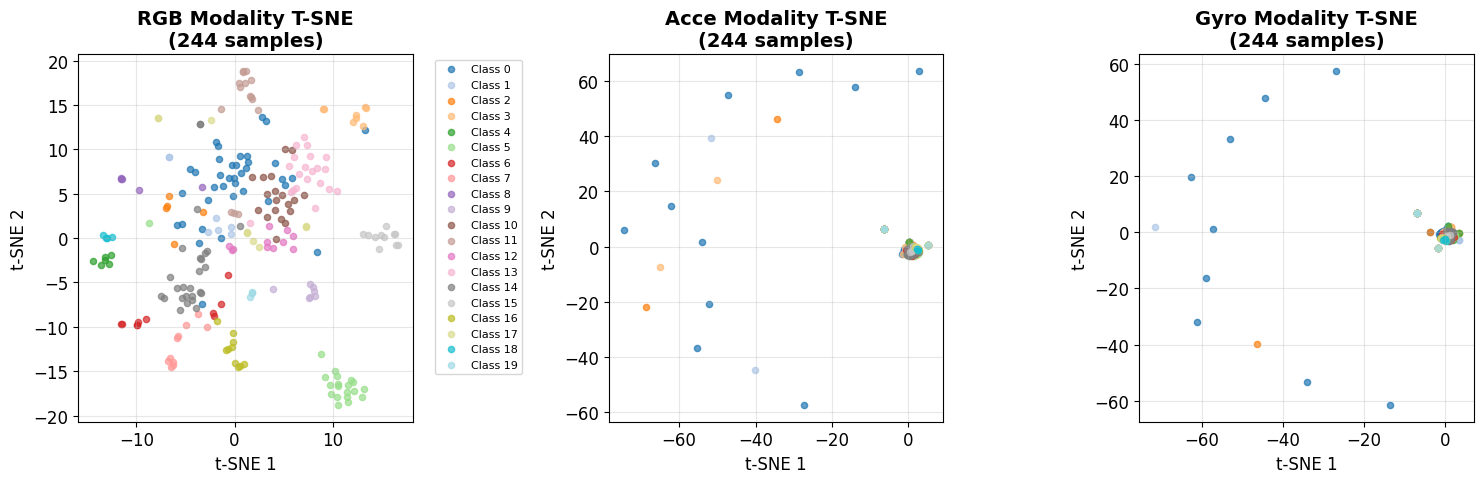

In [23]:
# T-SNE 시각화 실행
tsne_results_list = []
for features_dict, labels in zip(features_dict_list, labels_list):
    tsne_results, selected_labels = perform_tsne_visualization(features_dict, labels, config)
    tsne_results_list.append(tsne_results)

In [24]:
# Feature 분석 실행
# analyze_features(features_dict, labels, config)
for features_dict, labels in zip(features_dict_list, labels_list):
    analyze_features(features_dict, labels, config)

📊 Feature Analysis

🔍 RGB Modality:
   Shape: (244, 8192)
   Mean: 0.6531
   Std: 2.0778
   Min: 0.0000
   Max: 118.6990
   클래스별 feature 평균:
     Class 0: 0.5447 ± 1.8550
     Class 1: 0.6103 ± 1.9660
     Class 2: 1.1945 ± 3.4370
     Class 3: 1.6311 ± 4.5684
     Class 4: 0.9410 ± 3.2257
     Class 5: 0.8909 ± 2.6502
     Class 6: 0.7348 ± 1.6470
     Class 7: 0.7788 ± 1.6261
     Class 8: 0.6004 ± 1.3038
     Class 9: 0.6045 ± 1.3057
     Class 10: 0.4007 ± 1.6539
     Class 11: 0.5540 ± 2.0618
     Class 12: 0.4740 ± 1.6646
     Class 13: 0.4502 ± 1.7610
     Class 14: 0.6969 ± 1.6280
     Class 15: 0.5996 ± 1.5026
     Class 16: 0.6732 ± 1.6749
     Class 17: 0.3271 ± 1.5444
     Class 18: 0.8433 ± 2.2762
     Class 19: 0.5758 ± 1.3557

🔍 Acce Modality:
   Shape: (244, 8192)
   Mean: -0.0104
   Std: 0.0545
   Min: -0.3854
   Max: 0.2263
   클래스별 feature 평균:
     Class 0: -0.0104 ± 0.0545
     Class 1: -0.0104 ± 0.0545
     Class 2: -0.0104 ± 0.0545
     Class 3: -0.0104 ± 0.0545
  

## Result Save

In [ ]:
# # 결과 저장 및 요약
# def save_results(features_dict, tsne_results, labels, config, task_id):
#     """결과를 파일로 저장"""
    
#     # 결과 디렉토리 생성
#     results_dir = '/workspace/MMEA-OWCL/notebook/tsne_results'
#     os.makedirs(results_dir, exist_ok=True)
    
#     # Feature 저장
#     np.savez(
#         f'{results_dir}/features_{"_".join(config.modality)}_{task_id}.npz',
#         **features_dict,
#         labels=labels
#     )
    
#     # T-SNE 결과 저장
#     np.savez(
#         f'{results_dir}/tsne_{"_".join(config.modality)}_{task_id}.npz',
#         **tsne_results,
#         labels=labels
#     )
    
#     # 설정 저장
#     config_dict = {
#         'modality': config.modality,
#         'tsne_perplexity': config.tsne_perplexity,
#         'tsne_n_iter': config.tsne_n_iter,
#         'max_samples_per_class': config.max_samples_per_class,
#         'tsne_samples_per_class': config.tsne_samples_per_class,
#         'num_segments': config.num_segments
#     }
    
#     with open(f'{results_dir}/config_{"_".join(config.modality)}_{task_id}.json', 'w') as f:
#         json.dump(config_dict, f, indent=2)
    
#     print(f"✅ 결과 저장 완료: {results_dir}")
#     print(f"   Features: features_{'_'.join(config.modality)}_{task_id}.npz")
#     print(f"   T-SNE: tsne_{'_'.join(config.modality)}_{task_id}.npz")
#     print(f"   Config: config_{'_'.join(config.modality)}_{task_id}.json")

# # 결과 저장
# # save_results(features_dict, tsne_results, selected_labels, config)
# for task_id, (features_dict, tsne_results, selected_labels) in enumerate(zip(features_dict_list, tsne_results_list, labels_list)):
#     save_results(features_dict, tsne_results, selected_labels, config, task_id+1)

# # 최종 요약
# print("\n" + "="*60)
# print("🎯 T-SNE 시각화 완료!")
# print("="*60)
# print(f"📊 분석된 모달리티: {', '.join(config.modality)}")
# print(f"📈 전체 샘플 수: {len(labels)}")
# print(f"📈 T-SNE 시각화 샘플 수: {len(selected_labels)}")
# print(f"🏷️  클래스 수: {len(np.unique(labels))}")
# print(f"🔧 T-SNE 설정: perplexity={config.tsne_perplexity}, iterations={config.tsne_n_iter}")
# print(f"🔧 클래스별 샘플 수: {config.tsne_samples_per_class}개")
# print("\n💡 주요 발견사항:")
# print("   - 각 모달리티별 feature representation의 분포를 확인할 수 있습니다")
# print("   - 클래스별 클러스터링 패턴을 통해 모달리티의 구분력을 평가할 수 있습니다")
# print("   - 모달리티 간 상관관계를 통해 fusion의 효과를 예측할 수 있습니다")
# print("   - 클래스별 샘플 사이즈 제한으로 시각화 성능이 향상되었습니다")
# print("="*60)


✅ 결과 저장 완료: /workspace/MMEA-OWCL/notebook/tsne_results
   Features: features_RGB_Acce_Gyro_1.npz
   T-SNE: tsne_RGB_Acce_Gyro_1.npz
   Config: config_RGB_Acce_Gyro_1.json
✅ 결과 저장 완료: /workspace/MMEA-OWCL/notebook/tsne_results
   Features: features_RGB_Acce_Gyro_2.npz
   T-SNE: tsne_RGB_Acce_Gyro_2.npz
   Config: config_RGB_Acce_Gyro_2.json
✅ 결과 저장 완료: /workspace/MMEA-OWCL/notebook/tsne_results
   Features: features_RGB_Acce_Gyro_3.npz
   T-SNE: tsne_RGB_Acce_Gyro_3.npz
   Config: config_RGB_Acce_Gyro_3.json
✅ 결과 저장 완료: /workspace/MMEA-OWCL/notebook/tsne_results
   Features: features_RGB_Acce_Gyro_4.npz
   T-SNE: tsne_RGB_Acce_Gyro_4.npz
   Config: config_RGB_Acce_Gyro_4.json

🎯 T-SNE 시각화 완료!
📊 분석된 모달리티: RGB, Acce, Gyro
📈 전체 샘플 수: 244
📈 T-SNE 시각화 샘플 수: 244
🏷️  클래스 수: 20
🔧 T-SNE 설정: perplexity=30, iterations=1000
🔧 클래스별 샘플 수: 50개

💡 주요 발견사항:
   - 각 모달리티별 feature representation의 분포를 확인할 수 있습니다
   - 클래스별 클러스터링 패턴을 통해 모달리티의 구분력을 평가할 수 있습니다
   - 모달리티 간 상관관계를 통해 fusion의 효과를 예측할 수 있습니다
   - 클래